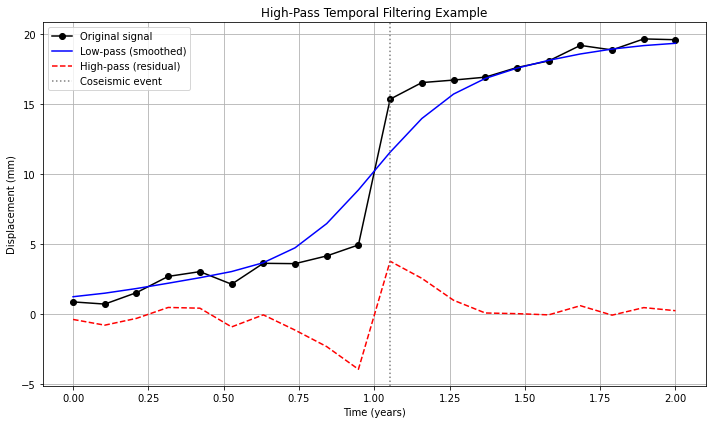

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a time series with 20 points
np.random.seed(0)
n_points = 20
time = np.linspace(0, 2, n_points)  # 2 years
true_signal = 5 * time  # Linear trend (e.g., tectonic)
event = np.zeros(n_points)
event[10:] += 10  # Coseismic jump at midpoint
noise = np.random.normal(0, 0.5, n_points)  # Small noise

# Total signal = slow trend + abrupt event + noise
displacement = true_signal + event + noise

# Apply Gaussian-weighted moving average (low-pass)
filtwidth_yr = 0.2  # Same as in example
weights = np.exp(-((time[:, None] - time[None, :]) ** 2) / (2 * filtwidth_yr ** 2))
weights /= weights.sum(axis=1, keepdims=True)
low_pass = (weights @ displacement)

# High-pass = original - low-pass
high_pass = displacement - low_pass

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(time, displacement, 'k-o', label='Original signal')
plt.plot(time, low_pass, 'b-', label='Low-pass (smoothed)')
plt.plot(time, high_pass, 'r--', label='High-pass (residual)')
plt.axvline(time[10], color='gray', linestyle=':', label='Coseismic event')
plt.title("High-Pass Temporal Filtering Example")
plt.xlabel("Time (years)")
plt.ylabel("Displacement (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import datetime as dt
import daz_lib_licsar as dl
import pandas as pd
# 1. Prepare the data
frame = '043A_05421_141313'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm


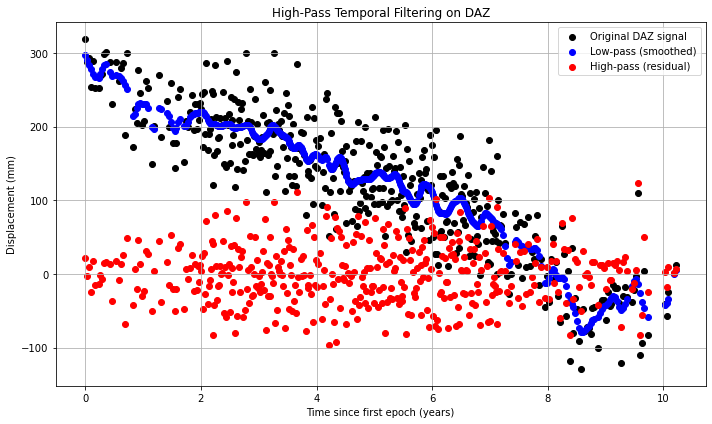

In [12]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import daz_lib_licsar as dl

# Load actual data
frame = '021D_05266_252525'
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm

# Convert dates to float time in years
t0 = dazes['epoch'].min()
time = (dazes['epoch'] - t0).dt.total_seconds() / (365.25 * 24 * 3600)
displacement = dazes['daz'].values

# Apply Gaussian-weighted moving average (low-pass filter)
filtwidth_yr = 0.059
weights = np.exp(-((time[:, None] - time[None, :]) ** 2) / (2 * filtwidth_yr ** 2))
weights /= weights.sum(axis=1, keepdims=True)
low_pass = weights @ displacement

# High-pass = original - low-pass
high_pass = displacement - low_pass

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(time, displacement, color='k', label='Original DAZ signal')    # black dots
plt.scatter(time, low_pass, color='blue', label='Low-pass (smoothed)')     # blue dots
plt.scatter(time, high_pass, color='red', label='High-pass (residual)')    # red dots
plt.title("High-Pass Temporal Filtering on DAZ")
plt.xlabel("Time since first epoch (years)")
plt.ylabel("Displacement (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


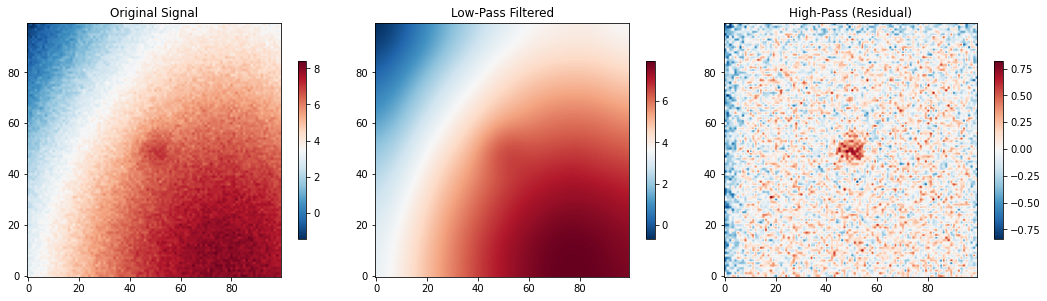

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import Gaussian2DKernel, convolve_fft

# Create synthetic 2D signal (100x100)
np.random.seed(0)
nx, ny = 100, 100

# Simulate spatial signal with both low- and high-frequency content
x = np.linspace(0, 10, nx)
y = np.linspace(0, 10, ny)
X, Y = np.meshgrid(x, y)

# Low-frequency trend (e.g., atmospheric ramp or orbit error)
low_freq = 5 * np.sin(0.2 * X) + 3 * np.cos(0.2 * Y)

# High-frequency local deformation
high_freq = np.exp(-((X - 5)**2 + (Y - 5)**2) / 0.5)

# Combine + add noise
signal = low_freq + high_freq + np.random.normal(0, 0.2, size=(ny, nx))

# Simulate spatial low-pass filter using Gaussian kernel
x_stddev = y_stddev = 5  # pixel units
kernel = Gaussian2DKernel(x_stddev, y_stddev)
low_pass = convolve_fft(signal, kernel, fill_value=np.nan)

# Subtract LP component to get spatial high-pass
high_pass = signal - low_pass

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes, [signal, low_pass, high_pass],
                           ["Original Signal", "Low-Pass Filtered", "High-Pass (Residual)"]):
    im = ax.imshow(data, cmap='RdBu_r', origin='lower')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()
